In [40]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from pathlib import Path
import ast
import matplotlib.dates as mdates
from datetime import timedelta
myFmt = mdates.DateFormatter('%H:%M:%S') 


In [59]:
def time_reader(fname):
    lines=open(fname).readlines()
    start_iter=0
    end_iter = 0
    counter=0
    str_dt = lines[0].strip().split(" Sync ")[0].split(".")[0].split(" ")[-1]
    start_iter = datetime.strptime(str_dt, "%H:%M:%S")
    core_times = [float(i.strip().split(" ")[-1]) for i in lines[4:8]]
    str_dt = lines[8].strip().split(" Sync ")[0].split(".")[0].split(" ")[-1]
    end_iter = datetime.strptime(str_dt, "%H:%M:%S")
    return (core_times, start_iter, end_iter)

def heat_reader(fname, st_iter, et_iter):
    lines=open(fname).readlines()
    et_iter = et_iter+timedelta(days=1) if et_iter < st_iter else et_iter
    run_trace = {}
    dt_iter=0
    for line in lines:
        l=line.strip()
        if "TIME" in l:
            str_dt = l.split("TIME:")[-1]
            dt_iter = datetime.strptime(str_dt, "%H:%M:%S")
            run_trace[dt_iter] = -1
            
        if "throttle" in l and dt_iter!=0: 
            # l=l.split("x")[-1]
            l=l.split("throttled=")[-1].split(",")[0]
            # print(l[1:5], "0000" != l[1:5])
            # run_trace[dt_iter]= 1 if l[-1]!='0' else 0
            if l[-1]=='0':
                run_trace[dt_iter]=0
            elif l[-1]=="5":
                run_trace[dt_iter]=1
            else:
                run_trace[dt_iter]=2

            dt_iter=0
    
    #date correction
    run_keys = list(run_trace.keys())
    # print(run_trace)
    filter_trace=[]
    if len(run_keys) > 0:
        corrected_trace = {run_keys[0]:run_trace[run_keys[0]]}
        for i in range(len(run_trace)-1):
            fixed_key = run_keys[i+1]
            if run_keys[i] > run_keys[i+1]:
                fixed_key=run_keys[i+1]+timedelta(days=1)
            corrected_trace[fixed_key] = run_trace[run_keys[i+1]]
        
        filter_trace= {}
        corrected_keys = list(corrected_trace.keys())
        for i in corrected_keys:
            if st_iter <= i <= et_iter:
                filter_trace[i] = corrected_trace[i]
    
    return filter_trace


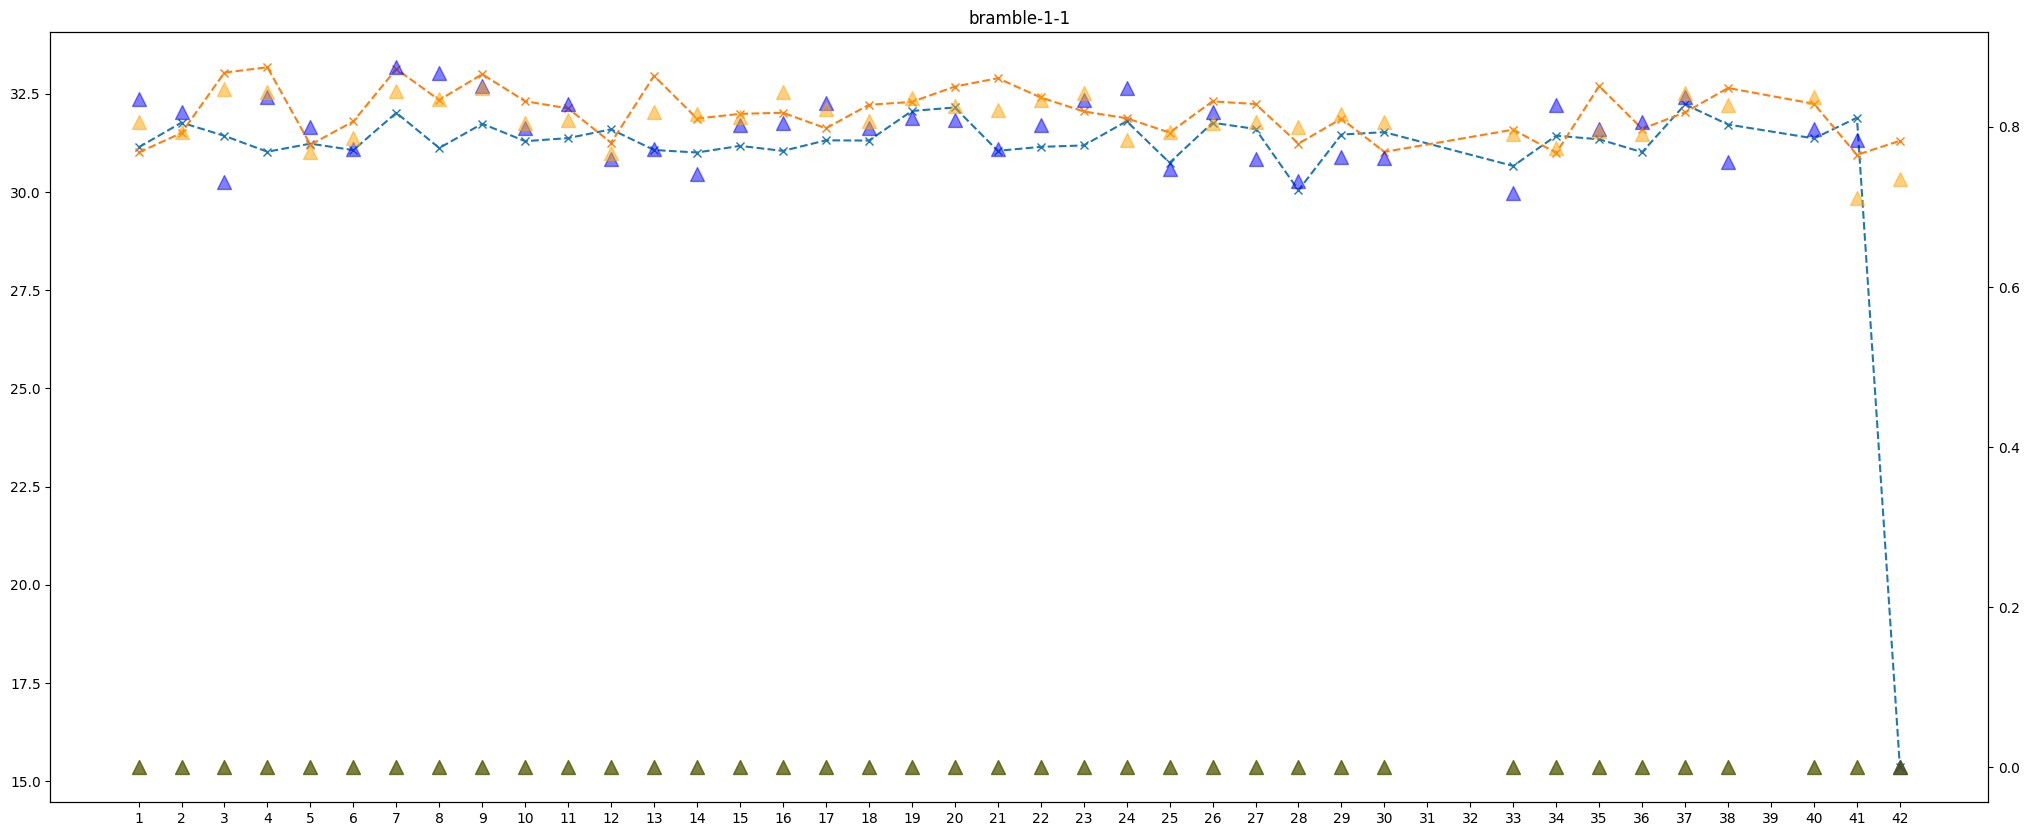

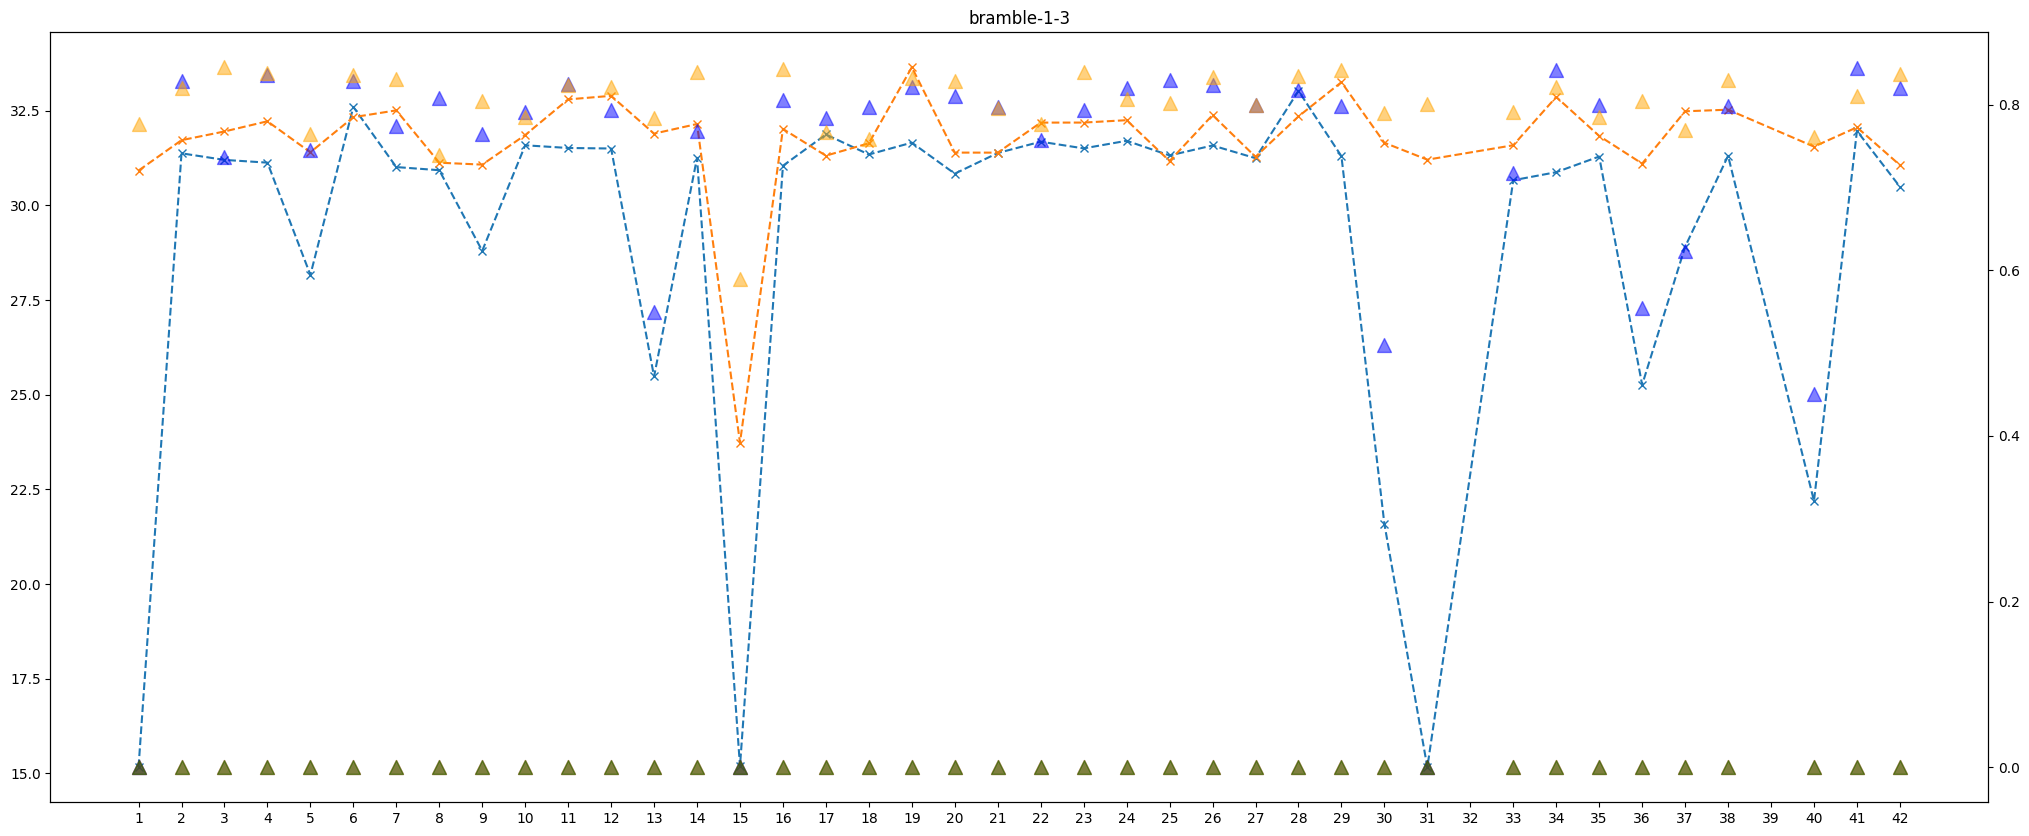

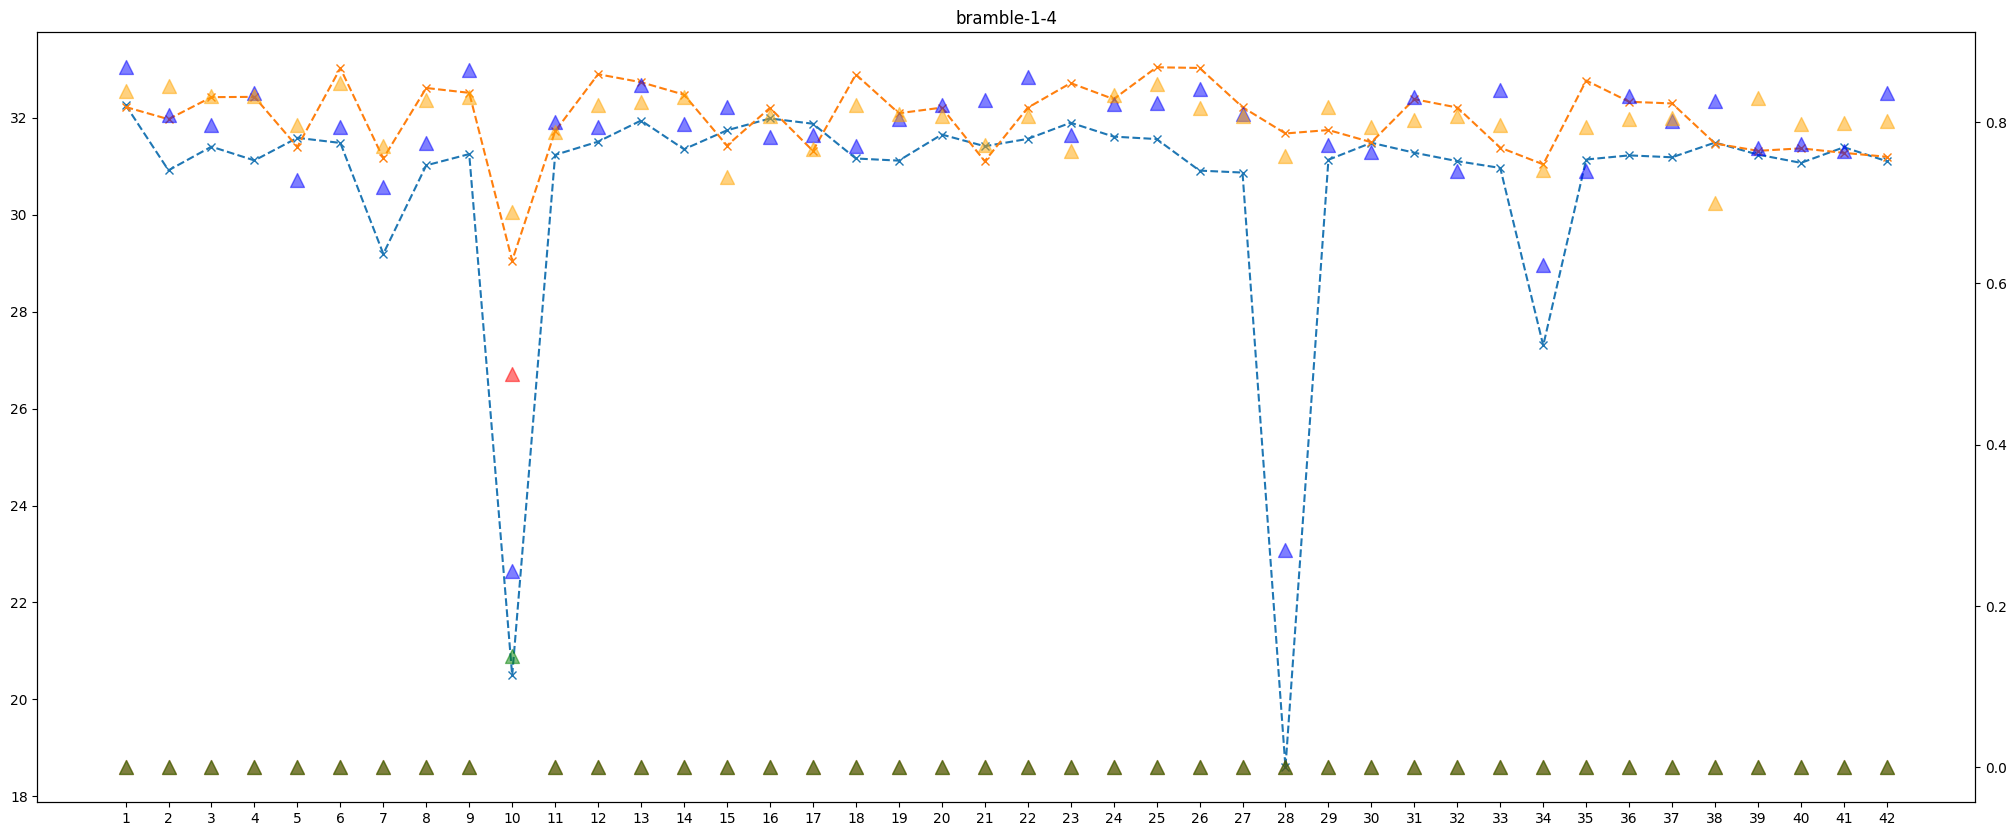

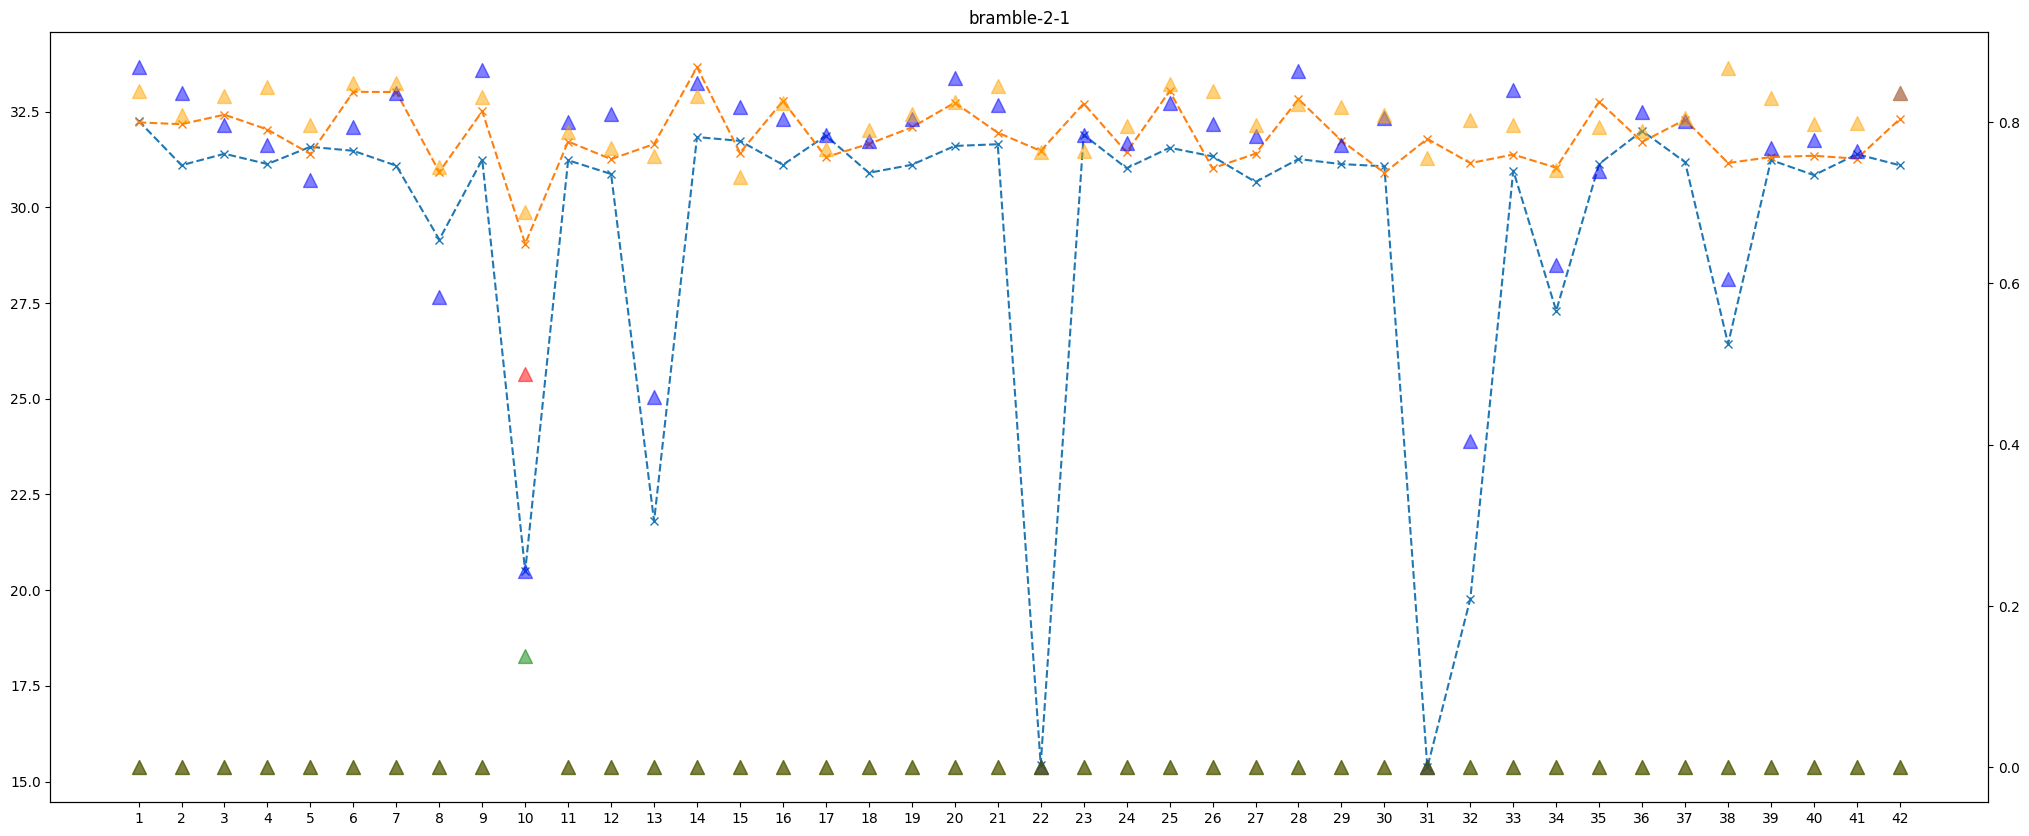

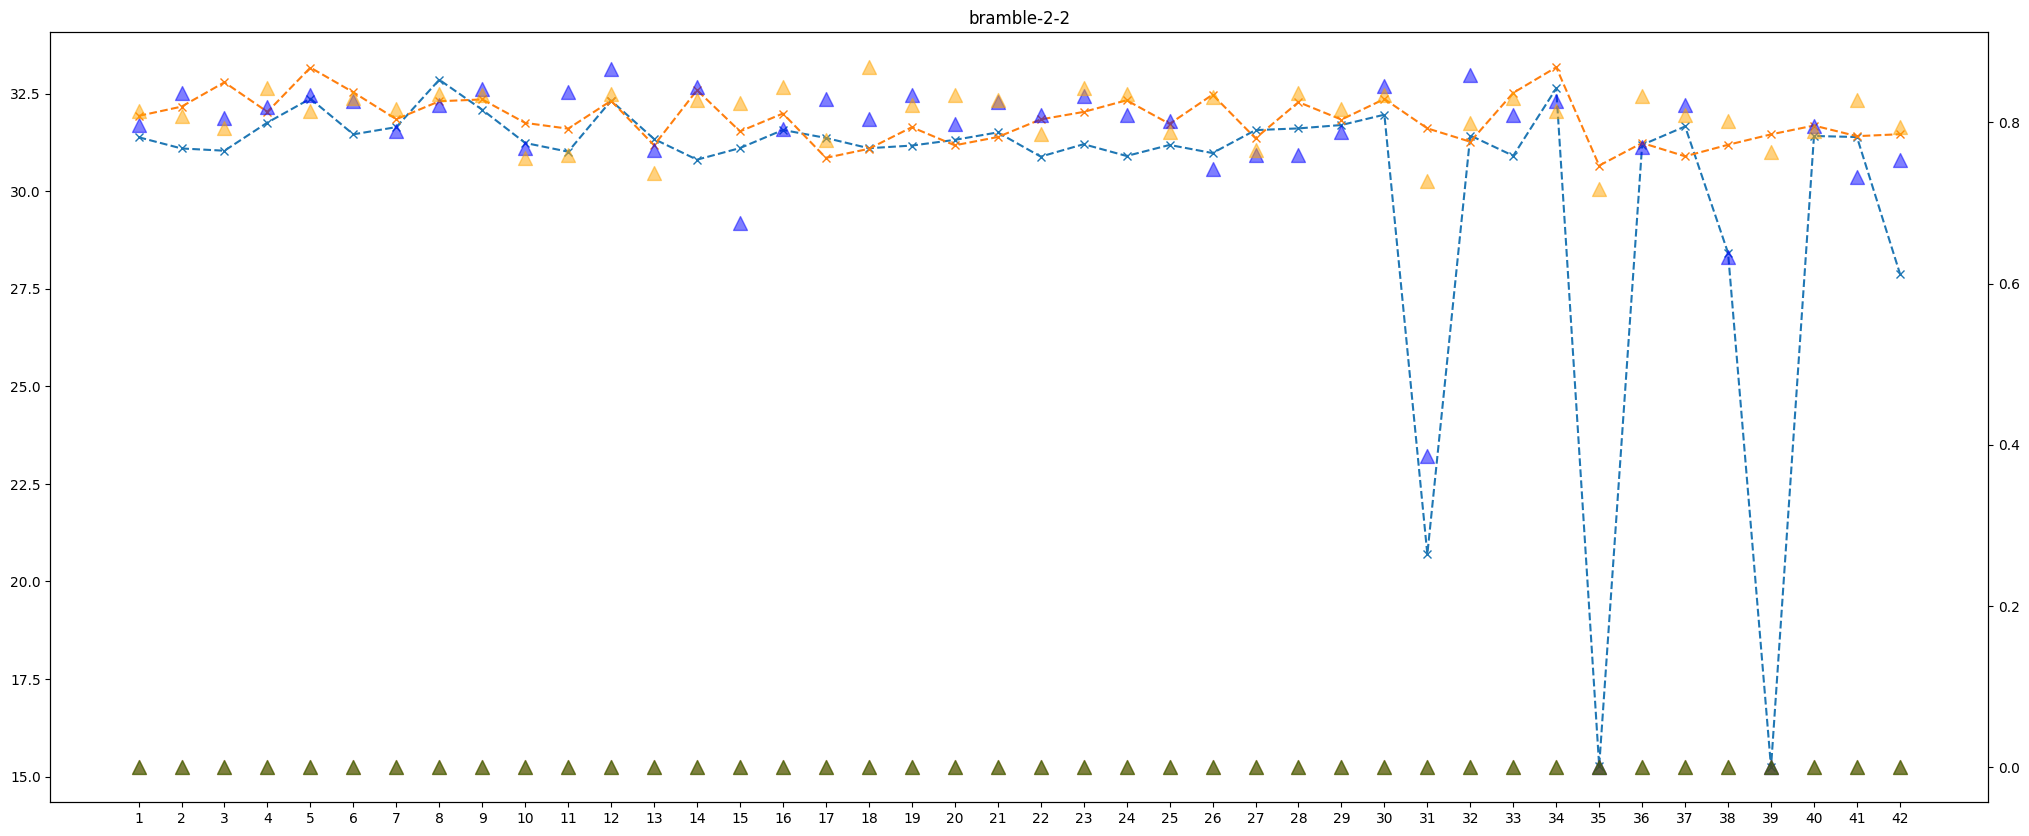

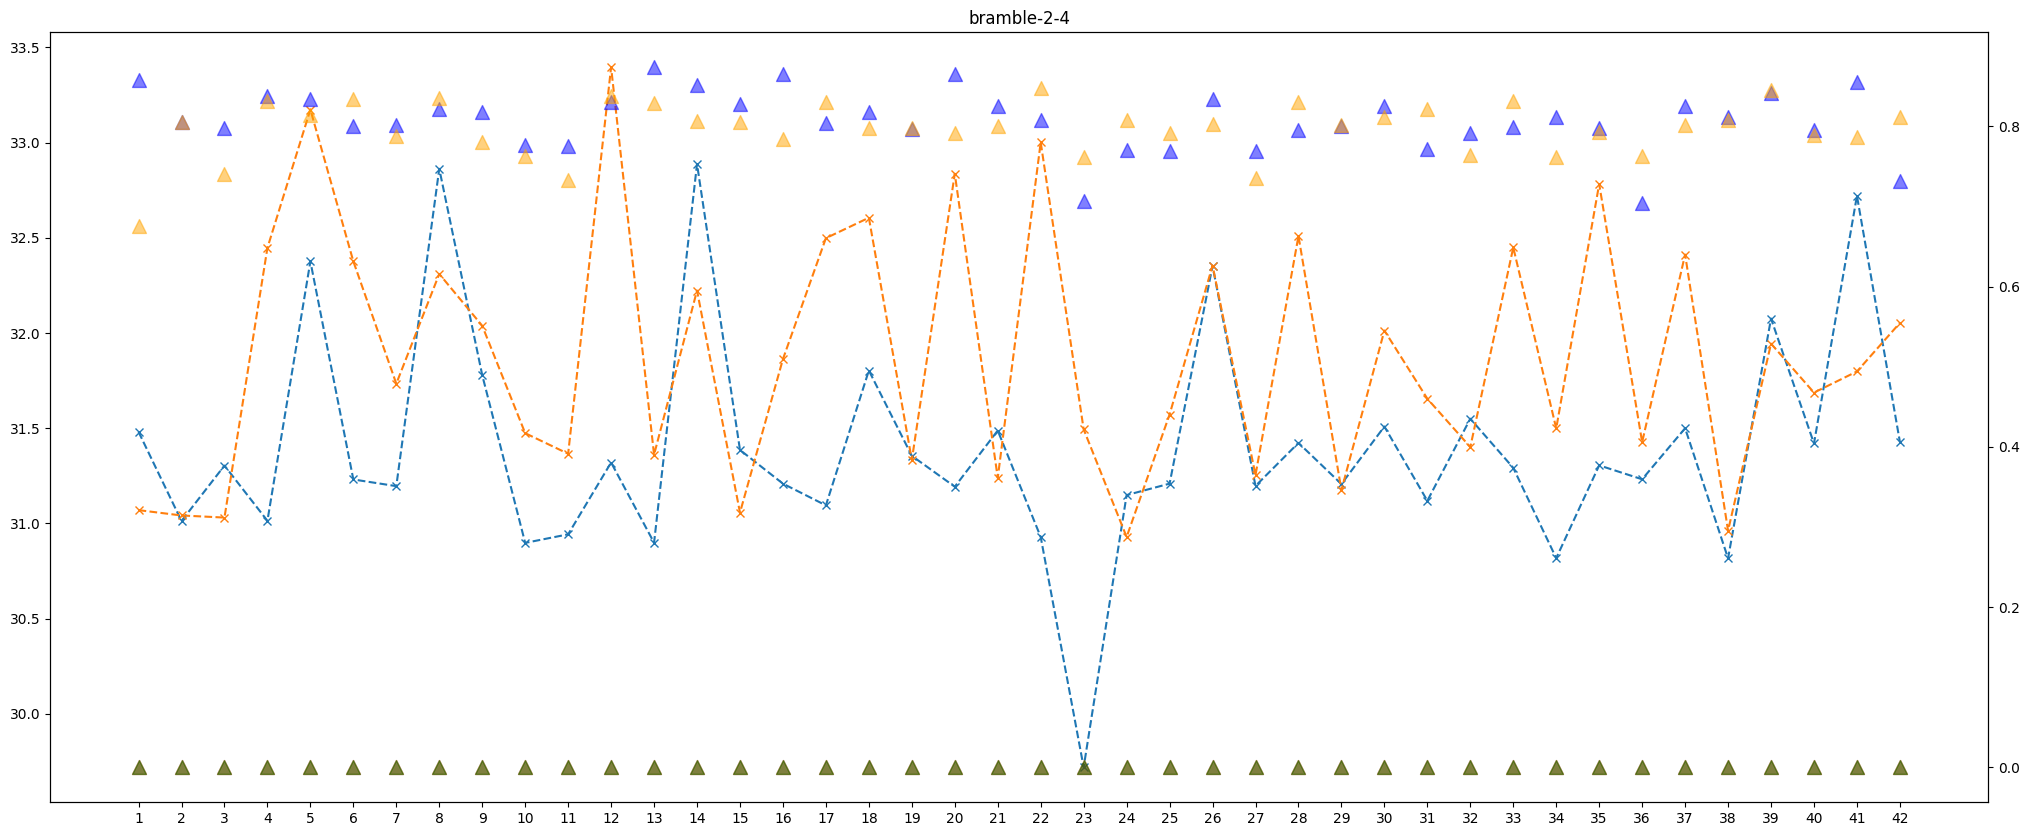

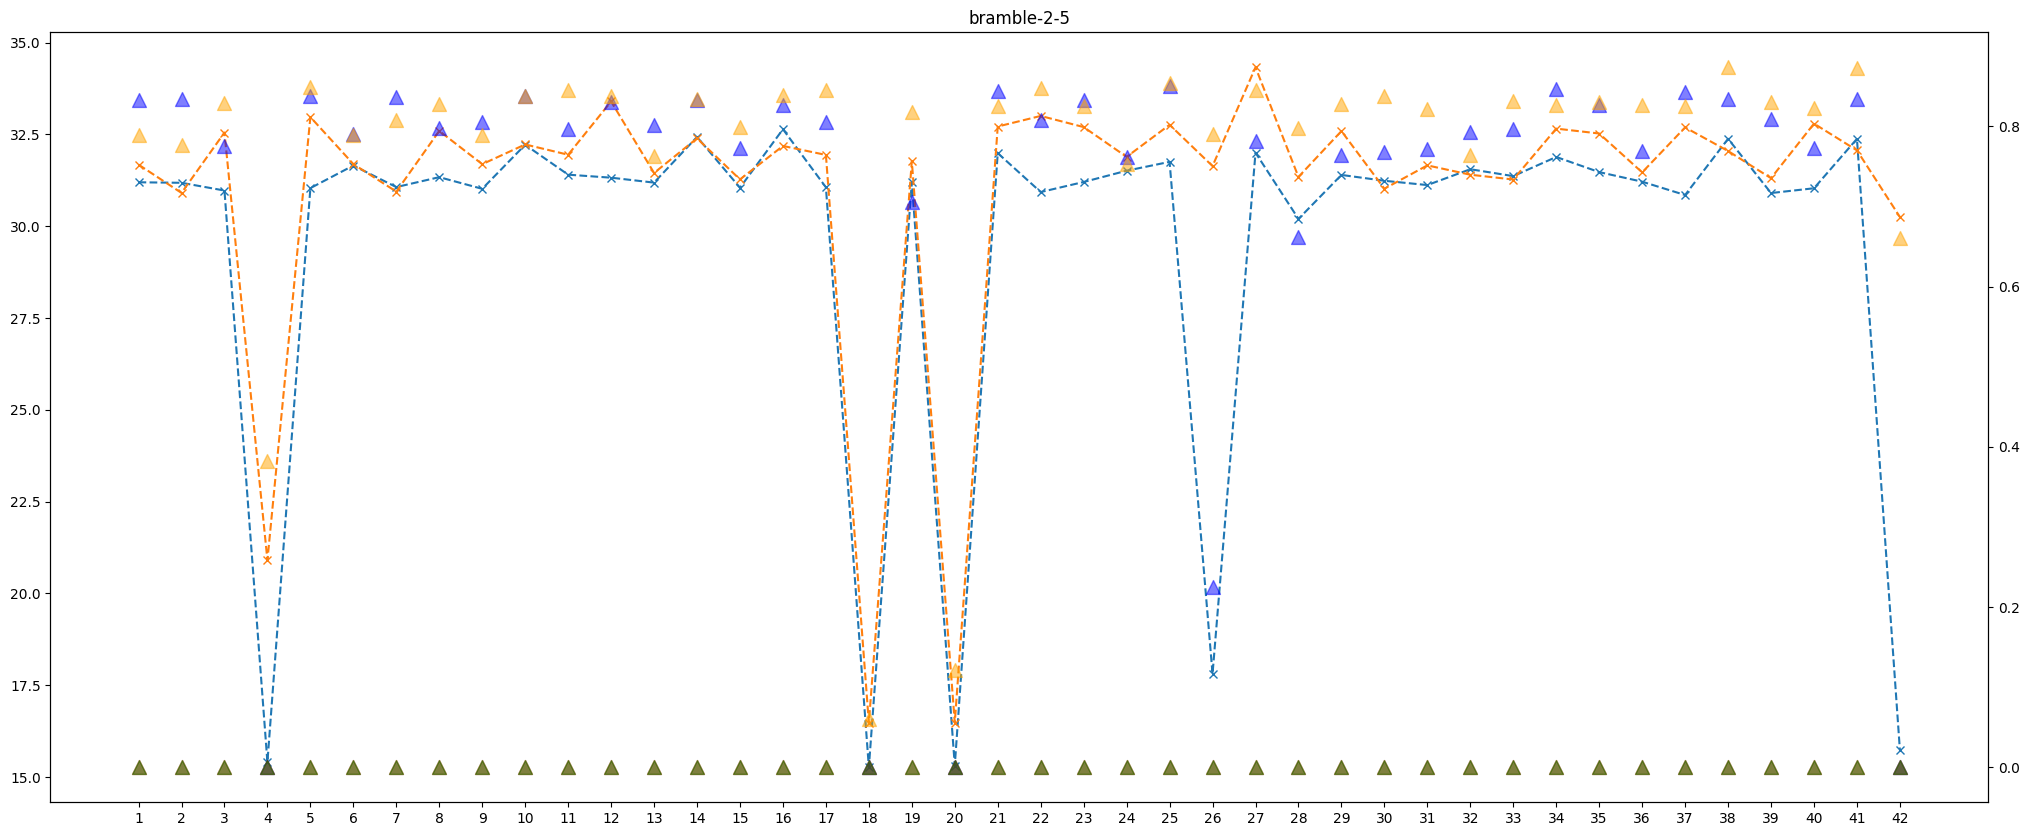

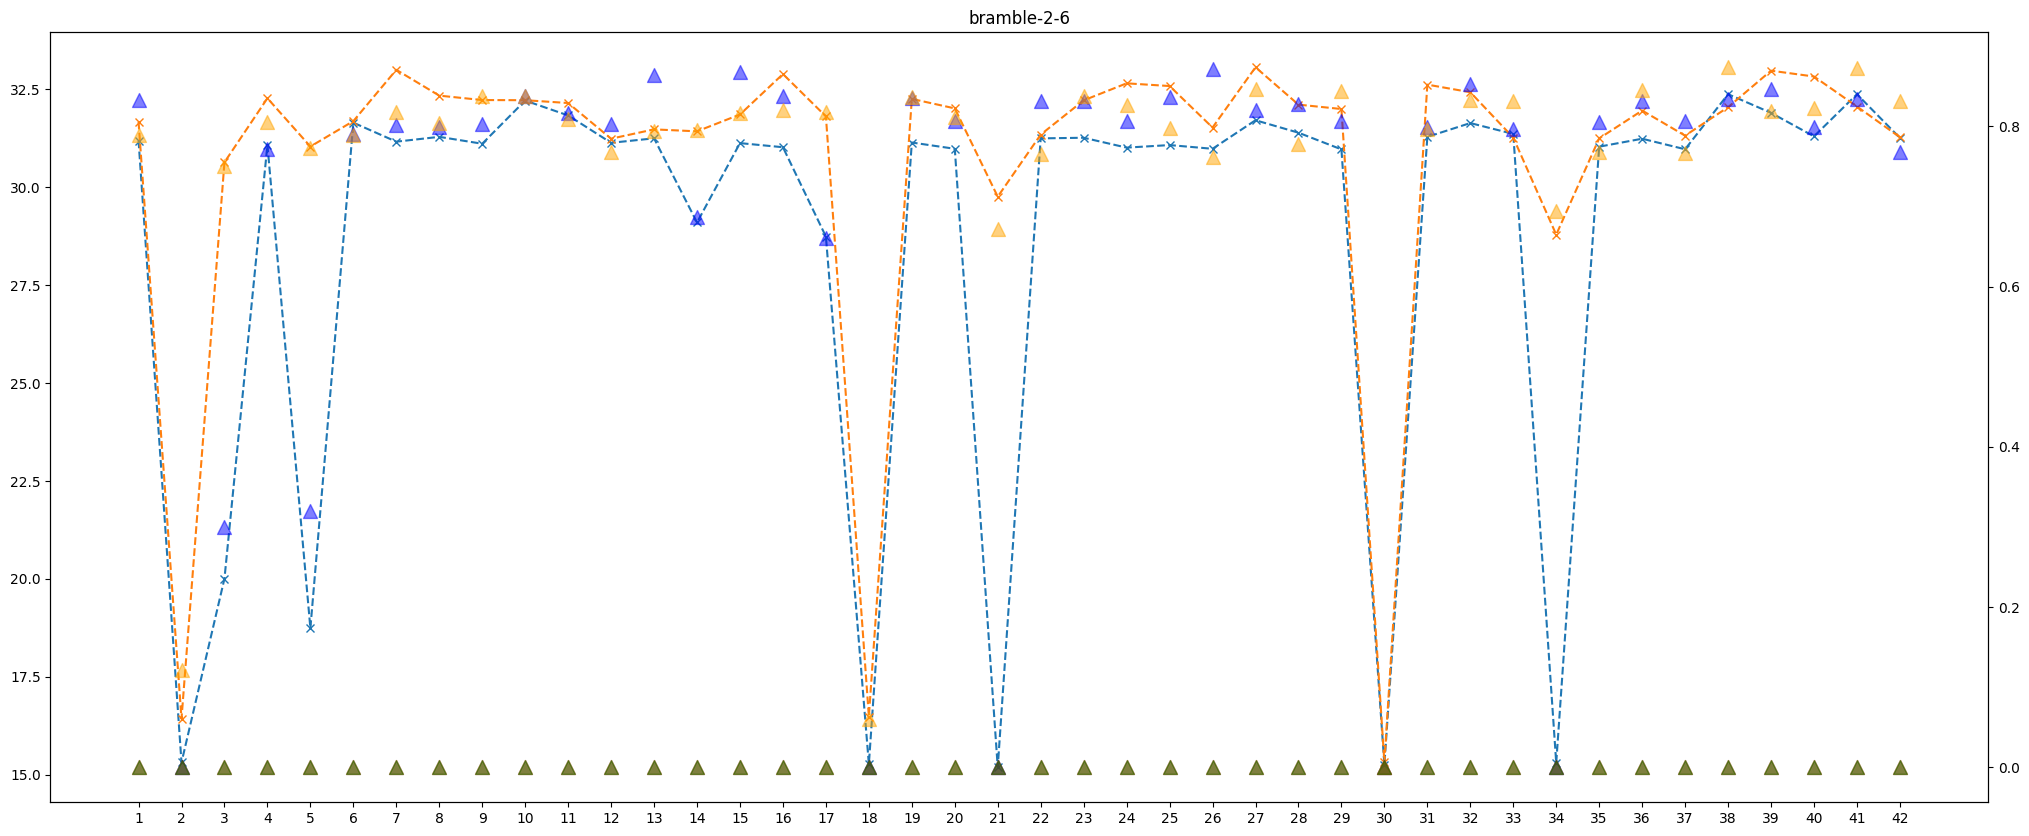

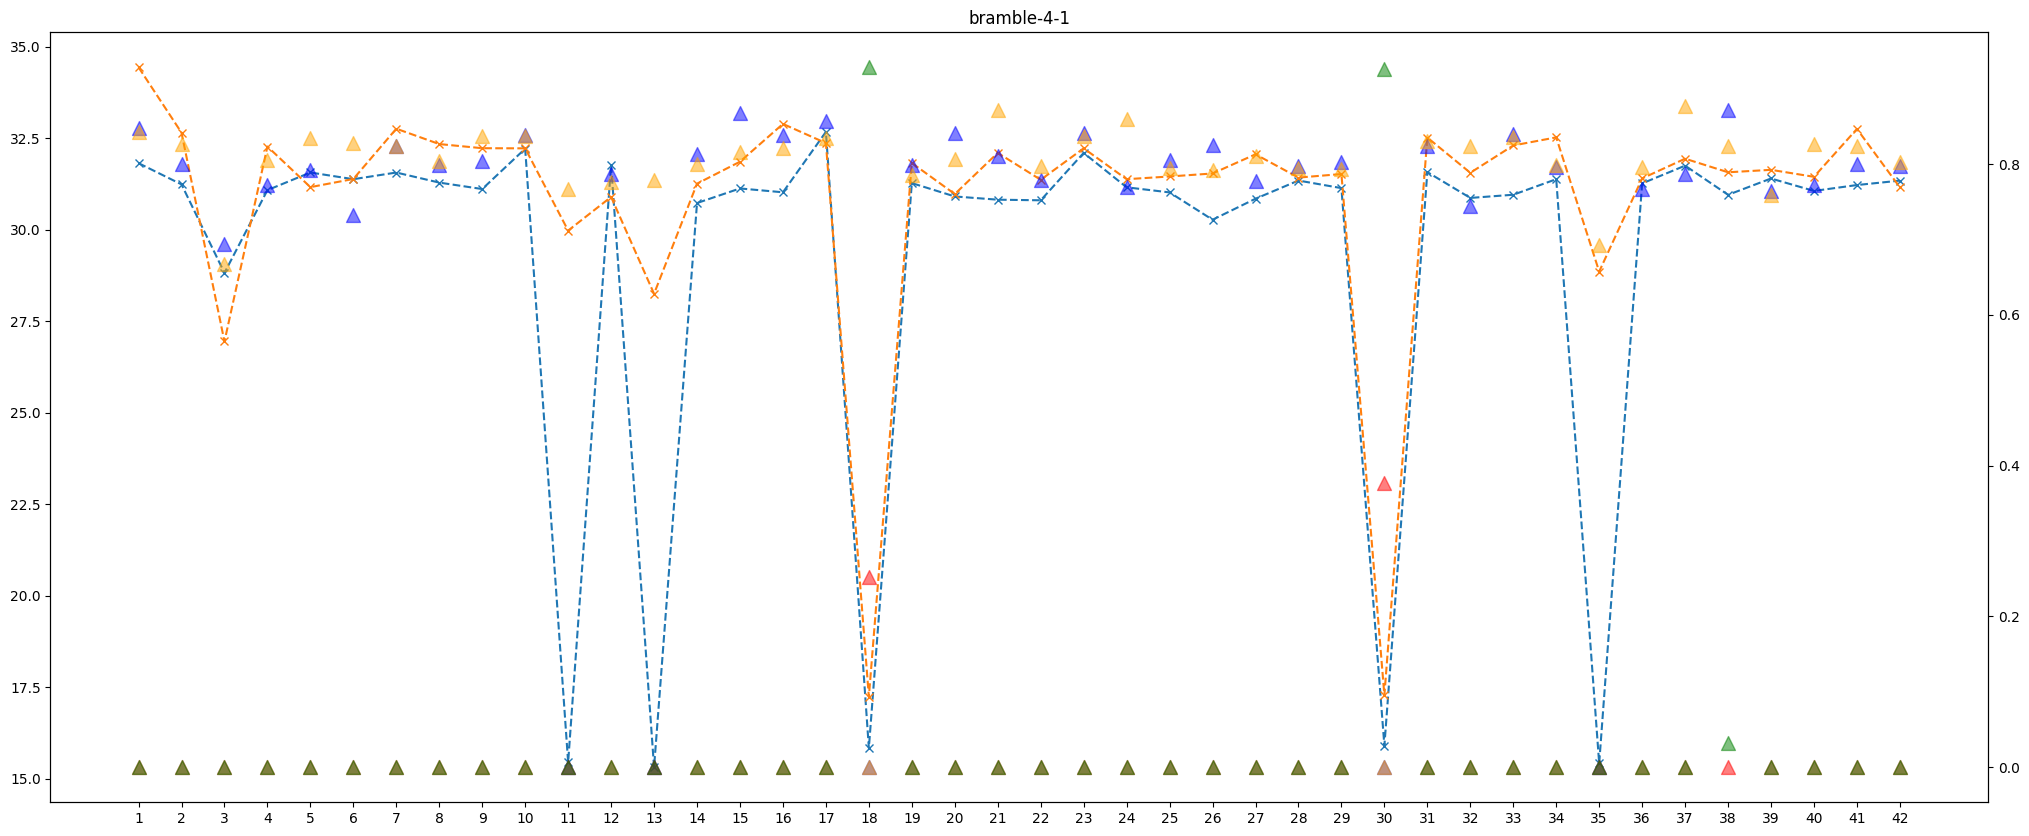

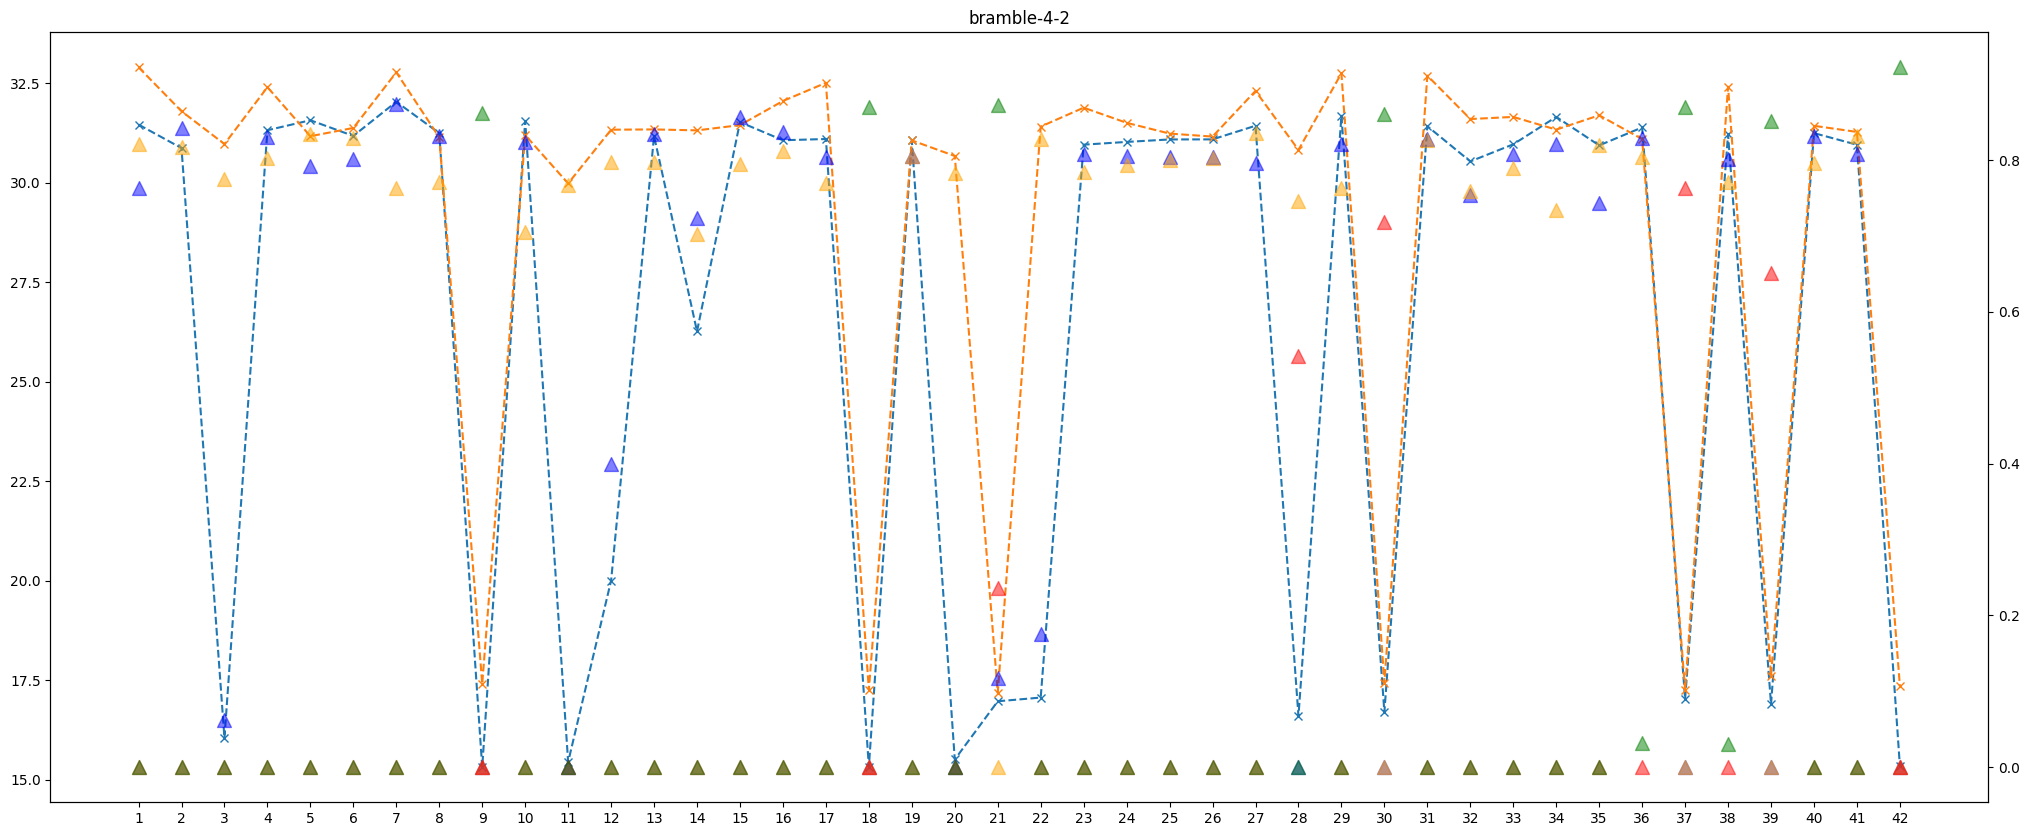

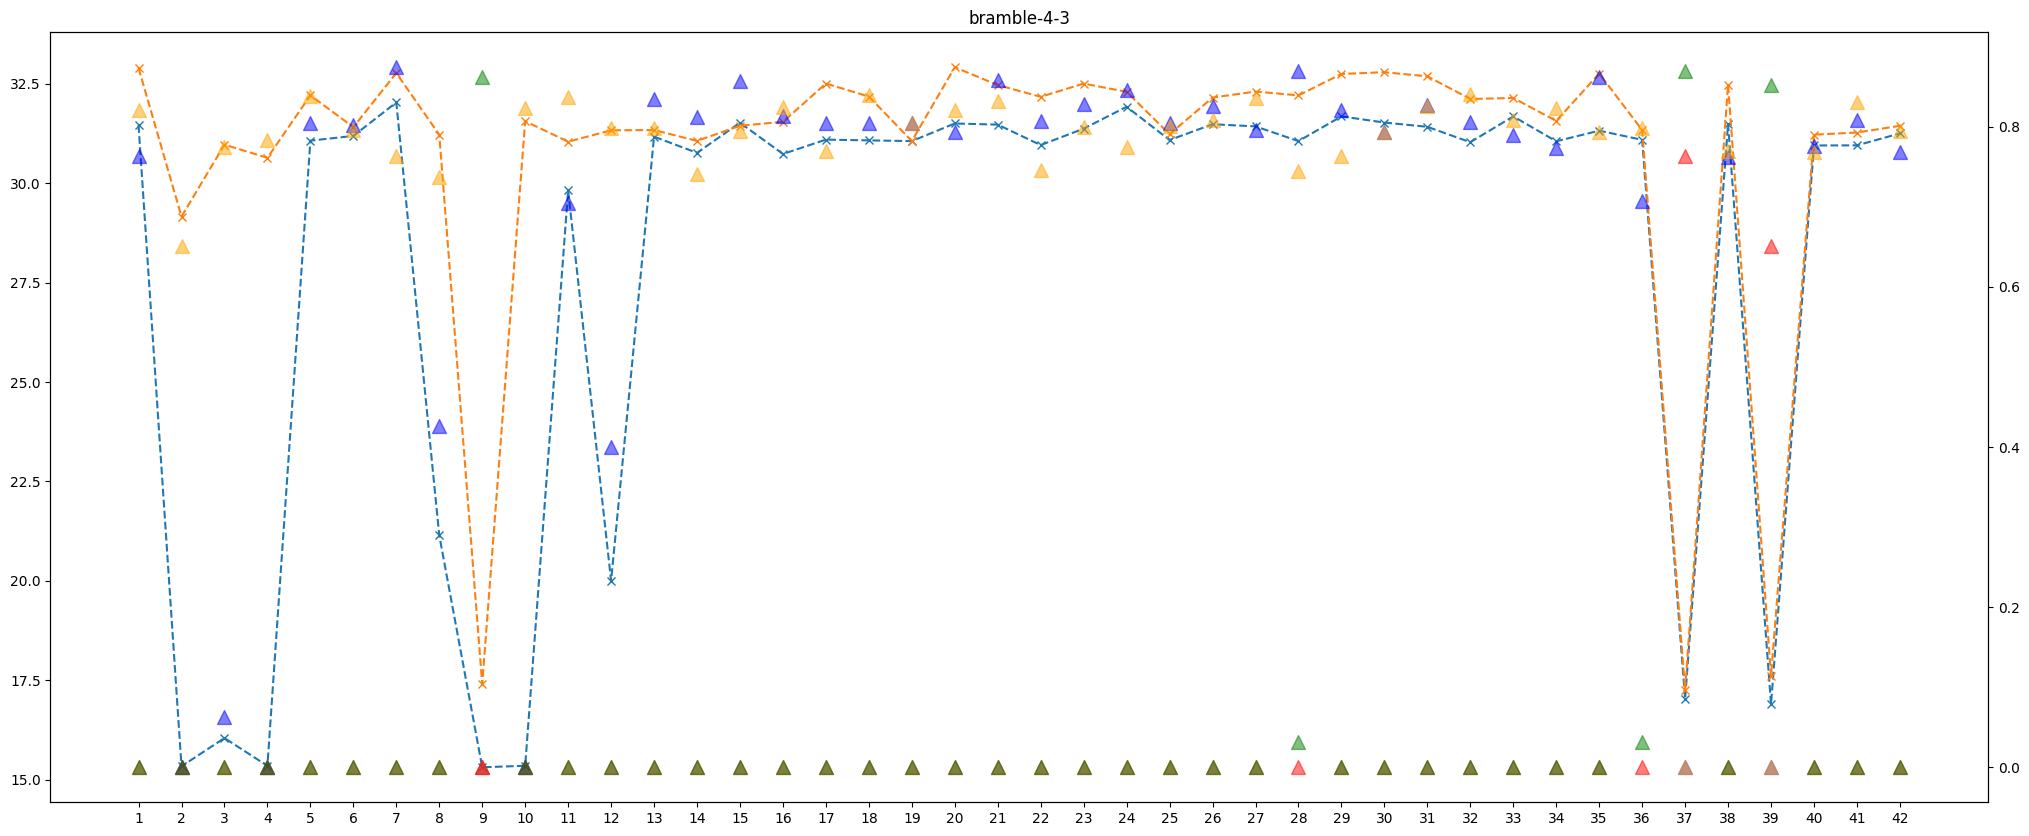

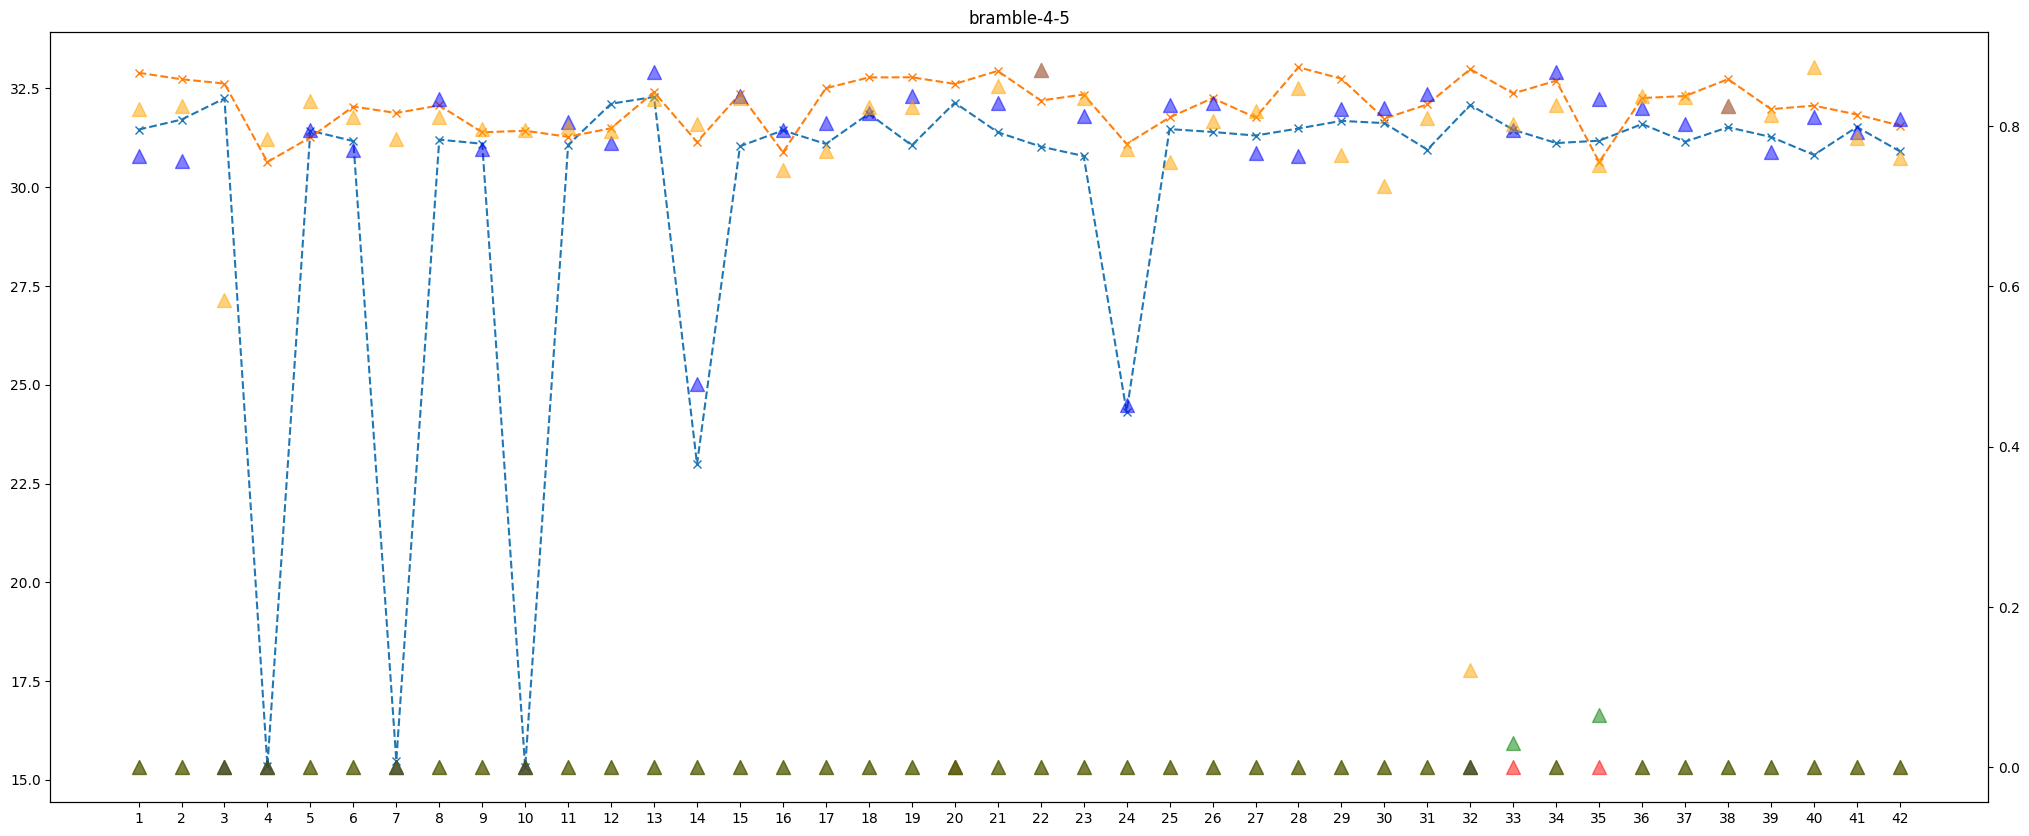

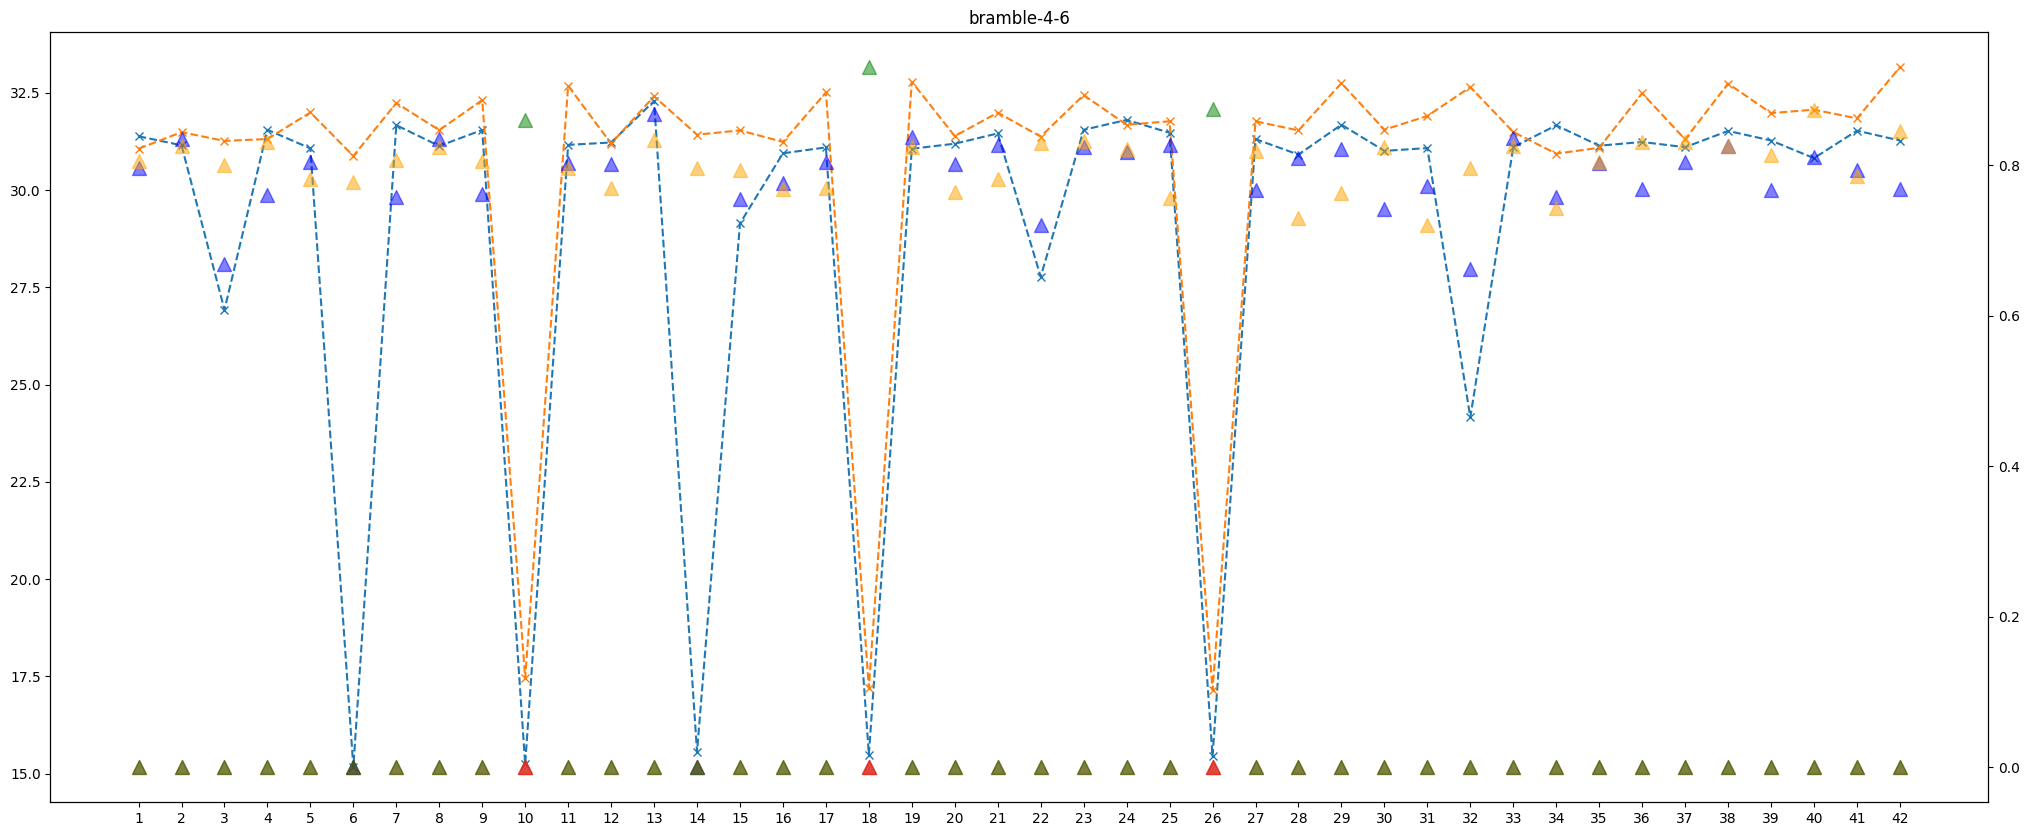

In [61]:
subclusters=["bramble-1-1", "bramble-1-3","bramble-1-4","bramble-2-1","bramble-2-2",
"bramble-2-4","bramble-2-5","bramble-2-6","bramble-4-1", "bramble-4-2","bramble-4-3","bramble-4-5","bramble-4-6"]

dev_map={}
for i in subclusters:
    fig, axs = plt.subplots(figsize=(25,10))
    for t in ["per_dev", "all_dev"]:
        for dev in range(1,43):
        # for dev in [42]:
            fname = f"/Users/animeshnd/model_splitting/logs/single_group_heat_con/{i}/{t}/0/speed_chronos{i}-{dev}.log"
            hname = f"/Users/animeshnd/model_splitting/logs/single_group_heat_con/{i}/{t}/0/speed_heat{i}-{dev}.log"
            if Path.is_file(Path(fname)):
                if dev not in dev_map:
                    dev_map[dev]={"per_dev":[], "all_dev":[]}
                core_times, s_dt, e_dt = time_reader(fname)
                # print(core_times)
                filter_trace = heat_reader(hname, s_dt, e_dt)
                if len(filter_trace)>0:
                    dev_map[dev][t] = [max(core_times), {'volt':len([1 for k in filter_trace if filter_trace[k]==1]), 
                    'temp': len([1 for k in filter_trace if filter_trace[k]==2])}]
                else:
                    print(fname)
                # print(filter_trace)
                # raise Exception("end it")

                # if len(filter_trace)>0:
                #     axs.plot(range(len(filter_trace)), filter_trace.values())
                # else:
                #     print(fname)
    # print(dev_map)
    sorted_keys = sorted([int(i) for i in dev_map.keys()])
    axs.plot(sorted_keys, [dev_map[i]["per_dev"][0] for i in sorted_keys], linestyle="--", marker="x")
    axs.plot(sorted_keys, [dev_map[i]["all_dev"][0] for i in sorted_keys], linestyle="--", marker="x")
    axs1=axs.twinx()
    axs1.scatter(sorted_keys, [dev_map[i]["per_dev"][1]['volt']/dev_map[i]["per_dev"][0] for i in sorted_keys], alpha=0.5, color="blue", marker="^", s=100)
    axs1.scatter(sorted_keys, [dev_map[i]["all_dev"][1]['volt']/dev_map[i]["all_dev"][0] for i in sorted_keys], alpha=0.5, color="orange", marker="^", s=100)
    axs1.scatter(sorted_keys, [dev_map[i]["per_dev"][1]['temp']/dev_map[i]["per_dev"][0] for i in sorted_keys], alpha=0.5, color="red", marker="^", s=100)
    axs1.scatter(sorted_keys, [dev_map[i]["all_dev"][1]['temp']/dev_map[i]["all_dev"][0] for i in sorted_keys], alpha=0.5, color="green", marker="^", s=100)
    axs.set_title(f"{i}")
    axs.set_xticks(np.arange(1,43,1))
    # raise Exception("end it")



